In [23]:
#importar comandos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import unicodedata
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [25]:
#Criar estrutura de pastas
RAIZ = Path(".")
PASTAS = [
"dados_brutos", "dados_tratados", "notebooks", "sql",
"dashboards", "relatorios", "apresentacao", "logs"
]
for pasta in PASTAS:
    (RAIZ / pasta).mkdir(parents=True, exist_ok=True)
print("Pastas verificadas/criadas:")
for pasta in PASTAS:
    print("-", RAIZ / pasta)

Pastas verificadas/criadas:
- dados_brutos
- dados_tratados
- notebooks
- sql
- dashboards
- relatorios
- apresentacao
- logs


In [29]:
#Definir parâmetros do projeto
ARQUIVO_BRUTO = Path("/content/dados_abertos_prf-datatran2025.csv")
ARQUIVO_BASE_ANALITICA = Path("dados_tratados/base_analitica_prf_2025.csv")
ARQUIVO_BASE_MODELAVEL = Path("dados_tratados/base_modelavel_prf_2025.csv")
ARQUIVO_DICIONARIO = Path("dados_tratados/dicionario_variaveis_modulo4.csv")
ARQUIVO_DECISOES = Path("logs/decisoes_tratamento_modulo4.md")
ARQUIVO_README = Path("README.md")
SEPARADOR = ";"
ENCODING_ENTRADA = "latin1"
ENCODING_SAIDA = "utf-8-sig"

In [31]:
#Ler o CSV da PRF com fallback de encoding
def ler_csv_prf(caminho, sep=";", encodings=("latin1", "utf-8", "utf-8-sig")):
    ultimo_erro = None
    for enc in encodings:
        try:
            print(f"Tentando leitura com encoding={enc}...")
            return pd.read_csv(caminho, sep=sep, encoding=enc, low_memory=False)
        except Exception as erro:
            ultimo_erro = erro
            print(f"Falhou com {enc}: {erro}")
    raise ultimo_erro
df = ler_csv_prf(ARQUIVO_BRUTO, sep=SEPARADOR)
df.head()

Tentando leitura com encoding=latin1...


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


### Acidentes por Estado (UF)
Vamos visualizar a distribuição dos acidentes por Unidade da Federação (UF) para entender onde a maioria dos acidentes ocorre.

/tmp/ipykernel_3993/1744622856.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='UF', y='Numero de Acidentes', data=uf_accident_counts, palette='viridis')


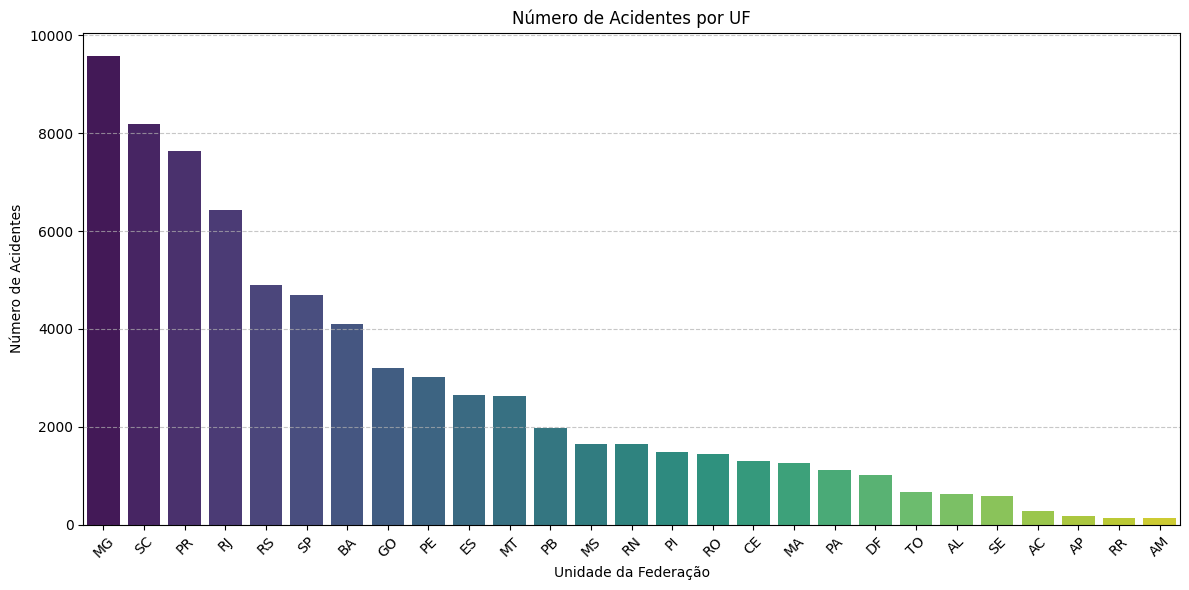

In [ ]:
uf_accident_counts = df['uf'].value_counts().reset_index()
uf_accident_counts.columns = ['UF', 'Numero de Acidentes']

plt.figure(figsize=(12, 6))
sns.barplot(x='UF', y='Numero de Acidentes', data=uf_accident_counts, palette='viridis')
plt.title('Número de Acidentes por UF')
plt.xlabel('Unidade da Federação')
plt.ylabel('Número de Acidentes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [33]:
#Padronizar nomes das colunas
def normalizar_nome_coluna(nome):
    nome = str(nome).strip().lower()
    nome = unicodedata.normalize("NFKD", nome).encode("ascii", "ignore").decode("utf-8")
    nome = nome.replace(" ", "_").replace("-", "_").replace("/", "_")
    while "__" in nome:
        nome = nome.replace("__", "_")
    return nome.strip("_")
df.columns = [normalizar_nome_coluna(c) for c in df.columns]
# Compatibilização de grafias possíveis
renomear = {"condicao_meteorologica": "condicao_metereologica"}
df = df.rename(columns={k: v for k, v in renomear.items() if k in df.columns})
print(df.columns.tolist())

['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']


In [35]:
#Conferir colunas esperadas
colunas_esperadas = [
"data_inversa", "dia_semana", "horario", "uf", "br", "municipio",
"causa_acidente", "tipo_acidente", "classificacao_acidente",
"fase_dia", "condicao_metereologica", "tipo_pista", "tracado_via",
"uso_solo", "pessoas", "mortos", "feridos_leves",
"feridos_graves", "feridos", "veiculos"
]
faltantes = [c for c in colunas_esperadas if c not in df.columns]
print("Colunas faltantes:", faltantes)
if faltantes:
    print("Atenção: ajuste nomes ou confirme o dicionário oficial da PRF usado no arquivo.")

Colunas faltantes: []


In [36]:
#Retrato inicial da base
print("Dimensões:", df.shape)
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])
display(df.head())
display(df.sample(5, random_state=42))

Dimensões: (72529, 30)
Linhas: 72529
Colunas: 30


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
6366,691804,2025-03-15,sábado,12:30:00,ES,101,67,SAO MATEUS,Condutor desrespeitou a iluminação vermelha do...,Colisão transversal,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Simples,Rotatória,Sim,4,0,0,2,1,2,2,4,"-18,72802869","-39,85997558",SPRF-ES,DEL04-ES,UOP02-DEL04-ES
9405,704622,2025-07-13,domingo,22:30:00,PE,423,"74,1",JUPI,Condutor deixou de manter distância do veículo...,Colisão traseira,Sem Vítimas,Plena Noite,Decrescente,Céu Claro,Simples,Aclive;Reta,Sim,2,0,0,0,2,0,0,2,"-8,7160879","-36,4219923",SPRF-PE,DEL03-PE,UOP01-DEL03-PE
26102,663260,2025-02-23,domingo,18:10:00,BA,242,231,ITABERABA,Animais na Pista,Atropelamento de Animal,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Sim,1,0,1,0,0,0,1,1,"-12,511706","-40,324247",SPRF-BA,DEL06-BA,UOP02-DEL06-BA
28616,667036,2025-03-13,quinta-feira,19:55:00,DF,20,"9,9",BRASILIA,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Dupla,Reta,Não,6,0,4,0,2,0,4,3,"-15,6502715","-47,7763723",SPRF-DF,DEL02-DF,UOP01-DEL02-DF
1696,660353,2025-02-09,domingo,19:05:00,MA,222,665,ACAILANDIA,Pedestre andava na pista,Atropelamento de Pedestre,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Declive,Não,3,0,1,1,0,1,2,3,"-4,89367779","-47,38426513",SPRF-MA,DEL04-MA,UOP03-DEL04-MA


In [37]:
#Tipos de dados e memória
df.info(memory_usage="deep")
resumo_tipos = (
df.dtypes.astype(str)
.value_counts()
.rename_axis("tipo")
.reset_index(name="qtd_colunas")
)
display(resumo_tipos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      72529 non-null  int64 
 1   data_inversa            72529 non-null  object
 2   dia_semana              72529 non-null  object
 3   horario                 72529 non-null  object
 4   uf                      72529 non-null  object
 5   br                      72529 non-null  int64 
 6   km                      72529 non-null  object
 7   municipio               72529 non-null  object
 8   causa_acidente          72529 non-null  object
 9   tipo_acidente           72529 non-null  object
 10  classificacao_acidente  72528 non-null  object
 11  fase_dia                72529 non-null  object
 12  sentido_via             72529 non-null  object
 13  condicao_metereologica  72529 non-null  object
 14  tipo_pista              72529 non-null  object
 15  tr

,tipo,qtd_colunas
0,object,20
1,int64,10


### Estatísticas Descritivas para Mortos e Feridos

Vamos analisar as estatísticas descritivas para as colunas `mortos` e `feridos` para entender a distribuição desses eventos nos acidentes.

In [ ]:
print('Estatísticas Descritivas para a coluna mortos:')
display(df['mortos'].describe())

print('\nEstatísticas Descritivas para a coluna feridos:')
display(df['feridos'].describe())

In [40]:
#Diagnóstico de valores ausentes
nulos = pd.DataFrame({
"qtd_nulos": df.isna().sum(),
"perc_nulos": df.isna().mean() * 100
}).sort_values("perc_nulos", ascending=False)
display(nulos[nulos["qtd_nulos"] > 0])

,qtd_nulos,perc_nulos
uop,38,0.052393
delegacia,22,0.030333
regional,2,0.002758
classificacao_acidente,1,0.001379


In [42]:
#Diagnóstico e remoção de duplicidades
qtd_duplicadas = df.duplicated().sum()
print("Duplicidades exatas:", qtd_duplicadas)
if qtd_duplicadas > 0:
    df = df.drop_duplicates().copy()
    print("Duplicidades removidas. Nova dimensão:", df.shape)

Duplicidades exatas: 0


In [43]:
#Cardinalidade das categorias
categoricas = df.select_dtypes(include="object").columns
cardinalidade = (
df[categoricas]
.nunique(dropna=True)
.sort_values(ascending=False)
.reset_index()
)
cardinalidade.columns = ["variavel", "qtd_categorias"]
display(cardinalidade.head(30))


,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


In [45]:
#Transformações e variáveis derivadas
#Converter colunas numéricas
colunas_numericas = [
    "br", "km", "pessoas", "mortos", "feridos", "feridos_leves",
    "feridos_graves", "ilesos", "ignorados", "veiculos"
]
for coluna in colunas_numericas:
    if coluna in df.columns:
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce")
print(df[[c for c in colunas_numericas if c in df.columns]].dtypes)

br                  int64
km                float64
pessoas             int64
mortos              int64
feridos             int64
feridos_leves       int64
feridos_graves      int64
ilesos              int64
ignorados           int64
veiculos            int64
dtype: object


In [46]:
#Tratar datas e criar variáveis temporais
df["data_inversa"] = pd.to_datetime(df["data_inversa"], errors="coerce")

df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["trimestre"] = df["data_inversa"].dt.quarter
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek
df["fim_de_semana"] = df["dia_semana_num"].isin([5, 6]).astype(int)
display(df[["data_inversa", "ano", "mes", "trimestre", "dia_semana_num",
"fim_de_semana"]].head())

,data_inversa,ano,mes,trimestre,dia_semana_num,fim_de_semana
0,2025-01-01,2025,1,1,2,0
1,2025-01-01,2025,1,1,2,0
2,2025-01-01,2025,1,1,2,0
3,2025-01-01,2025,1,1,2,0
4,2025-01-01,2025,1,1,2,0


In [48]:
#Tratar horário e criar turno
horario_limpo = df["horario"].astype(str).str.strip()
df["hora"] = pd.to_datetime(horario_limpo, format="%H:%M:%S", errors="coerce").dt.hour
# Tentativa alternativa para arquivos com HH:MM
faltou_hora = df["hora"].isna()
if faltou_hora.any():
    df.loc[faltou_hora, "hora"] = pd.to_datetime(
        horario_limpo[faltou_hora], format="%H:%M", errors="coerce"
    ).dt.hour
def classificar_turno(hora):
    if pd.isna(hora):
        return "IGNORADO"
    if 0 <= hora <= 5:
        return "MADRUGADA"
    if 6 <= hora <= 11:
        return "MANHA"
    if 12 <= hora <= 17:
        return "TARDE"
    return "NOITE"
df["turno"] = df["hora"].apply(classificar_turno)
display(df[["horario", "hora", "turno"]].head())

,horario,hora,turno
0,06:20:00,6,MANHA
1,07:50:00,7,MANHA
2,08:45:00,8,MANHA
3,11:00:00,11,MANHA
4,09:30:00,9,MANHA


### Número de Mortos por Turno

Vamos analisar a distribuição de fatalidades ('mortos') de acordo com o turno do dia para identificar padrões.

/tmp/ipykernel_3993/1055991364.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='turno', y='mortos', data=mortos_por_turno, palette='viridis')


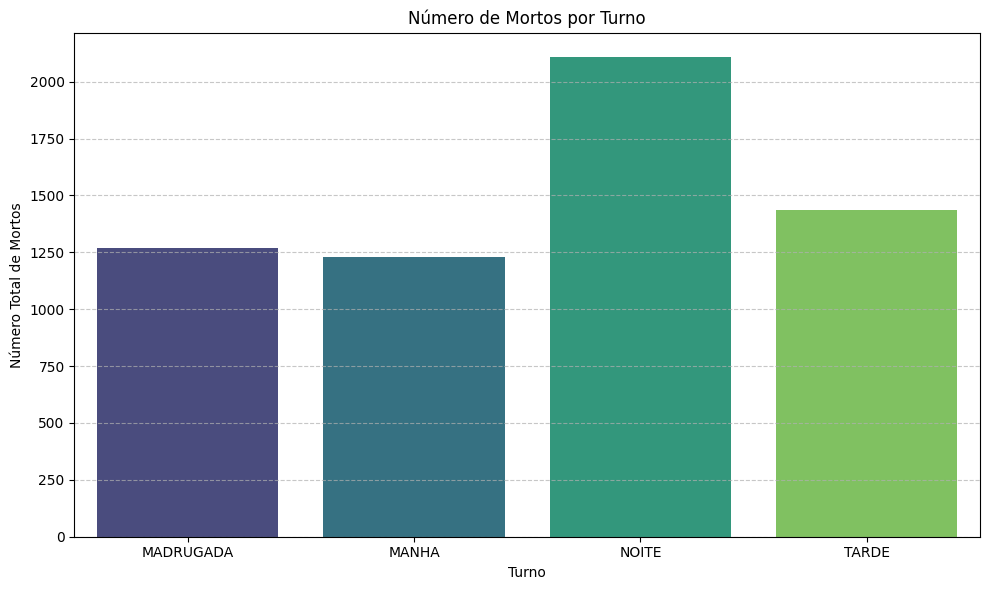

In [49]:
mortos_por_turno = df.groupby('turno')['mortos'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='turno', y='mortos', data=mortos_por_turno, palette='viridis')
plt.title('Número de Mortos por Turno')
plt.xlabel('Turno')
plt.ylabel('Número Total de Mortos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [51]:
#Criar faixa horária
def criar_faixa_horaria(hora):
  if pd.isna(hora):
    return "IGNORADO"
  inicio = int(hora // 3) * 3
  fim = inicio + 2
  return f"{inicio:02d}h-{fim:02d}h"
df["faixa_horaria"] = df["hora"].apply(criar_faixa_horaria)
display(df["faixa_horaria"].value_counts(dropna=False).sort_index())

,count
faixa_horaria,
00h-02h,3959
03h-05h,4948
06h-08h,11517
09h-11h,9342
12h-14h,9678
15h-17h,12624
18h-20h,13473
21h-23h,6988


In [61]:
colunas_texto = df.select_dtypes(include="object").columns
for coluna in colunas_texto:
 df[coluna] = (
  df[coluna]
   .astype("string")
.str.strip()
.str.upper()
)
df[coluna] = df[coluna].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "NULL": pd.NA})
print("Colunas textuais padronizadas:", len(colunas_texto))

Colunas textuais padronizadas: 0


In [62]:
#Tratar nulos categóricos
categoricas_importantes = [
"uf", "municipio", "causa_acidente", "tipo_acidente", "fase_dia",
"condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo",
"classificacao_acidente", "dia_semana"
]
for coluna in categoricas_importantes:
 if coluna in df.columns:
  df[coluna] = df[coluna].fillna("IGNORADO")
print(df[categoricas_importantes].isna().sum().sort_values(ascending=False))

uf                        0
municipio                 0
causa_acidente            0
tipo_acidente             0
fase_dia                  0
condicao_metereologica    0
tipo_pista                0
tracado_via               0
uso_solo                  0
classificacao_acidente    0
dia_semana                0
dtype: int64


In [63]:
#Tratar nulos numéricos de contagem
contagens_vitimas = ["mortos", "feridos", "feridos_leves", "feridos_graves", "pessoas",
"veiculos"]
for coluna in contagens_vitimas:
  if coluna in df.columns:
    df[coluna] = df[coluna].fillna(0)
print(df[[c for c in contagens_vitimas if c in df.columns]].isna().sum())

mortos            0
feridos           0
feridos_leves     0
feridos_graves    0
pessoas           0
veiculos          0
dtype: int64


In [65]:
#Variável-alvo e indicadores de gravidade
#Criar variável-alvo acidente_fatal
df["acidente_fatal"] = np.where(df["mortos"] >= 1, 1, 0)
validacao_alvo =df["acidente_fatal"].value_counts(dropna=False).rename_axis("acidente_fatal").reset_index(name="qtd")
validacao_alvo["perc"] = validacao_alvo["qtd"] / validacao_alvo["qtd"].sum() * 100
display(validacao_alvo)
display(validacao_alvo)

,acidente_fatal,qtd,perc
0,0,67319,92.816666
1,1,5210,7.183334


In [66]:
#Validar logicamente o alvo
violacoes = df.loc[
((df["mortos"] >= 1) & (df["acidente_fatal"] != 1)) |
((df["mortos"] == 0) & (df["acidente_fatal"] != 0))
]
print("Violações da regra do alvo:", len(violacoes))
assert len(violacoes) == 0, "Há erro na criação de acidente_fatal."

Violações da regra do alvo: 0


In [67]:
#Criar indicadores de gravidade
df["total_vitimas"] = df["mortos"] + df["feridos_leves"] + df["feridos_graves"]
df["acidente_grave"] = np.where(
(df["mortos"] >= 1) | (df["feridos_graves"] >= 1),
1,
0
)
df["indice_gravidade"] = (
df["mortos"] * 3
+ df["feridos_graves"] * 2
+ df["feridos_leves"]
)
display(df[["mortos", "feridos_leves", "feridos_graves", "total_vitimas",
"indice_gravidade"]].head())

,mortos,feridos_leves,feridos_graves,total_vitimas,indice_gravidade
0,0,1,0,1,1
1,1,1,0,2,4
2,0,3,0,3,3
3,0,1,0,1,1
4,0,1,1,2,3


In [68]:
#Criar BR formatada e chave de localidade
def formatar_br(valor):
 if pd.isna(valor) or valor == 0:
  return "BR-IGNORADA"
  return f"BR-{int(valor):03d}"
df["br_formatada"] = df["br"].apply(formatar_br)
df["chave_localidade"] = (
df["uf"].astype(str) + "_" +
df["municipio"].astype(str) + "_" +
df["br_formatada"].astype(str)
)
display(df[["uf", "municipio", "br", "br_formatada", "chave_localidade"]].head())

,uf,municipio,br,br_formatada,chave_localidade
0,SP,GUARULHOS,116,None,SP_GUARULHOS_None
1,CE,PENAFORTE,116,None,CE_PENAFORTE_None
2,PR,CORNELIO PROCOPIO,369,None,PR_CORNELIO PROCOPIO_None
3,PR,CAMPINA GRANDE DO SUL,116,None,PR_CAMPINA GRANDE DO SUL_None
4,MG,FRANCISCO SA,251,None,MG_FRANCISCO SA_None


In [69]:
#Checagens rápidas após transformação
checagens = {
"linhas": len(df),
"colunas": df.shape[1],
"acidentes_fatais": int(df["acidente_fatal"].sum()),
"taxa_fatalidade": float(df["acidente_fatal"].mean()),
"total_mortos": int(df["mortos"].sum()),
 "total_feridos": int(df["feridos"].sum()) if "feridos" in df.columns else None,
}
checagens

{'linhas': 72529,
 'colunas': 44,
 'acidentes_fatais': 5210,
 'taxa_fatalidade': 0.07183333563126473,
 'total_mortos': 6043,
 'total_feridos': 83550}

In [70]:
#Ranking rápido de categorias
def ranking_categoria(base, coluna, n=10):
 return (
 base[coluna]
.value_counts(dropna=False)
.head(n)
.rename_axis(coluna)
.reset_index(name="qtd")
)
display(ranking_categoria(df, "causa_acidente", 10))
display(ranking_categoria(df, "tipo_acidente", 10))

,causa_acidente,qtd
0,AUSÊNCIA DE REAÇÃO DO CONDUTOR,11469
1,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,10799
2,ACESSAR A VIA SEM OBSERVAR A PRESENÇA DOS OUTR...,7097
3,CONDUTOR DEIXOU DE MANTER DISTÂNCIA DO VEÍCULO...,4413
4,VELOCIDADE INCOMPATÍVEL,4088
5,MANOBRA DE MUDANÇA DE FAIXA,4016
6,INGESTÃO DE ÁLCOOL PELO CONDUTOR,3685
7,DEMAIS FALHAS MECÂNICAS OU ELÉTRICAS,3385
8,TRANSITAR NA CONTRAMÃO,2475
9,CONDUTOR DORMINDO,2116


,tipo_acidente,qtd
0,COLISÃO TRASEIRA,14360
1,SAÍDA DE LEITO CARROÇÁVEL,10209
2,COLISÃO TRANSVERSAL,9306
3,COLISÃO LATERAL MESMO SENTIDO,7885
4,TOMBAMENTO,6351
5,COLISÃO COM OBJETO,5109
6,COLISÃO FRONTAL,4739
7,QUEDA DE OCUPANTE DE VEÍCULO,3450
8,ATROPELAMENTO DE PEDESTRE,3057
9,COLISÃO LATERAL SENTIDO OPOSTO,2152


In [71]:
#Taxa fatal por categoria
def taxa_fatal_por_categoria(base, coluna, min_registros=30):
 tab = base.groupby(coluna).agg(
qtd_acidentes=("acidente_fatal", "size"),
qtd_fatais=("acidente_fatal", "sum"),
taxa_fatal=("acidente_fatal", "mean")
).reset_index()
 tab = tab[tab["qtd_acidentes"] >= min_registros]
 return tab.sort_values("taxa_fatal", ascending=False)
display(taxa_fatal_por_categoria(df, "tipo_acidente", min_registros=30).head(10))

,tipo_acidente,qtd_acidentes,qtd_fatais,taxa_fatal
1,ATROPELAMENTO DE PEDESTRE,3057,902,0.295061
4,COLISÃO FRONTAL,4739,1396,0.294577
6,COLISÃO LATERAL SENTIDO OPOSTO,2152,212,0.098513
11,EVENTOS ATÍPICOS,287,23,0.080139
0,ATROPELAMENTO DE ANIMAL,1133,68,0.060018
14,SAÍDA DE LEITO CARROÇÁVEL,10209,605,0.059261
3,COLISÃO COM OBJETO,5109,297,0.058133
2,CAPOTAMENTO,1373,63,0.045885
7,COLISÃO TRANSVERSAL,9306,427,0.045884
8,COLISÃO TRASEIRA,14360,619,0.043106


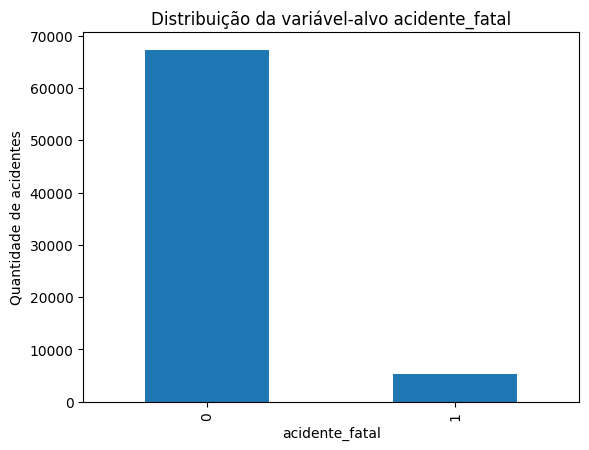

In [72]:
#Gráfico simples de conferência
ax = df["acidente_fatal"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Distribuição da variável-alvo acidente_fatal")
ax.set_xlabel("acidente_fatal")
ax.set_ylabel("Quantidade de acidentes")
plt.show()

In [73]:
#Construção das bases finais e documentação
#Construção das duas bases (analítica e modelável)
#Conceito de base analítica completa
#Gerar base analítica completa
base_analitica = df.copy()
print("Base analítica:", base_analitica.shape)
print("Colunas:", base_analitica.columns.tolist())

Base analítica: (72529, 44)
Colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'ano', 'mes', 'trimestre', 'dia_semana_num', 'fim_de_semana', 'hora', 'turno', 'faixa_horaria', 'acidente_fatal', 'total_vitimas', 'acidente_grave', 'indice_gravidade', 'br_formatada', 'chave_localidade']


In [76]:
from google.colab import files

#Conceito de base modelável
uploaded = files.upload()

arquivo = list(uploaded.keys())[0]

# Tenta abrir com diferentes configurações de codificação
try:
    df = pd.read_csv(arquivo, sep=';', encoding='utf-8')
except:
    try:
        df = pd.read_csv(arquivo, sep=';', encoding='latin1')
    except:
        df = pd.read_csv(arquivo, encoding='latin1')

print("\nArquivo carregado:", arquivo)
print("Quantidade de linhas:", len(df))
print("Quantidade de colunas:", len(df))
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\n=== COLUNAS ENCONTRADAS ===")
for coluna in df.columns:
    print("-", coluna)

# Refactoring the 'mortos' and 'acidente_fatal' creation outside the loop
if "mortos" in df.columns:
    df["mortos"] = pd.to_numeric(
        df["mortos"],
        errors="coerce"
    ).fillna(0)

    df["acidente_fatal"] = np.where(
        df["mortos"] > 0,
        1,
        0
    )
    print("\nVariável alvo criada: acidente_fatal")
else:
    print("\nATENÇÃO: a coluna 'mortos' não foi encontrada.")
    print("Verifique o nome da coluna no arquivo.")

ALVO = "acidente_fatal"
proibidas = [
"mortos",
ALVO,
"feridos_graves",
"feridos_leves",
"ilesos",
"ignorados"
]

duvidosas = [
"pessoas",
"veiculos"
]
permitidas = [
"uf",
"br",
"km",
"municipio",
"causa_acidente",
"tipo_acidente",
"classificacao_acidente",
"fase_dia",
"sentido_via",
"condicao_metereologica",
"condicao_meteorologica",
"tipo_pista",
"tracado_via",
"uso_solo",
"dia_semana",
"horario"
]

permitidas_existentes = [
coluna for coluna in permitidas
if coluna in df.columns
]

proibidas_existentes = [
coluna for coluna in proibidas
if coluna in df.columns
]

duvidosas_existentes = [
coluna for coluna in duvidosas
if coluna in df.columns
]

print("\n")
print("=" * 70)
print("CLASSIFICAÇÃO DAS VARIÁVEIS")
print("=" * 70)

print("\n🟢 VARIÁVEIS PERMITIDAS")
print("-" * 40)

if permitidas_existentes:
    for coluna in permitidas_existentes:
        print("✔", coluna)
else:
    print("Nenhuma variável permitida encontrada.")


print("\n🔴 VARIÁVEIS PROIBIDAS")
print("-" * 40)

if proibidas_existentes:
    for coluna in proibidas_existentes:
        print("✘", coluna)
else:
    print("Nenhuma variável proibida encontrada.")


print("\n🟡 VARIÁVEIS DUVIDOSAS")
print("-" * 40)

if duvidosas_existentes:
    for coluna in duvidosas_existentes:
        print("?", coluna)
else:
    print("Nenhuma variável duvidosa encontrada.")

# Ensure colunas_modelo is always defined
colunas_modelo = permitidas_existentes + [ALVO]

base_modelavel = df[colunas_modelo].copy()
print("\n")
print("=" * 70)
print("BASE MODELÁVEL")
print("=" * 70)

print("\nDimensões:")
print("Linhas:", base_modelavel.shape[0])
print("Colunas:", base_modelavel.shape[1])

print("\nPrimeiras 10 linhas:")
display(base_modelavel.head(10))

print("\n")
print("=" * 70)
print("DISTRIBUIÇÃO DO ALVO — acidente_fatal")
print("=" * 70)

print(
    base_modelavel["acidente_fatal"]
    .value_counts()
    .sort_index()
)


# Percentual
percentuais = (
    base_modelavel["acidente_fatal"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\nPercentual:")
print(percentuais)

classificacao = []

for coluna in df.columns:

    if coluna == ALVO:
        categoria = "ALVO"
        motivo = "Variável que a árvore de decisão deve prever."

    elif coluna in proibidas_existentes:
        categoria = "PROIBIDA"
        motivo = "Relacionada diretamente ao desfecho ou pode causar vazamento."

    elif coluna in duvidosas_existentes:
        categoria = "DUVIDOSA"
        motivo = "Pode representar informação relacionada ao desfecho."

    elif coluna in permitidas_existentes:
        categoria = "PERMITIDA"
        motivo = "Variável explicativa disponível antes ou durante o acidente."

    else:
        categoria = "ANALISAR"
        motivo = "Necessita avaliação antes de entrar no modelo."

    classificacao.append({
        "variavel": coluna,
        "classificacao": categoria,
        "motivo": motivo
    })
    # tabela_classificacao should be created outside the loop after all appends
tabela_classificacao = pd.DataFrame(classificacao)

print("\n")
print("=" * 70)
print("TABELA DE CLASSIFICAÇÃO")
print("=" * 70)

display(tabela_classificacao)

print("\n")
print("=" * 70)
print("RESUMO — CONCEITO DE BASE MODELÁVEL")
print("=" * 70)

print(f"""




Total de registros: {len(base_modelavel)}
Total de variáveis explicativas: {len(colunas_modelo)-1}
Total de variáveis proibidas encontradas: {len(proibidas_existentes)}
Total de variáveis duvidosas encontradas: {len(duvidosas_existentes)}
""")

Saving dados_abertos_prf-datatran2025.csv to dados_abertos_prf-datatran2025 (2).csv

Arquivo carregado: dados_abertos_prf-datatran2025 (2).csv
Quantidade de linhas: 72529
Quantidade de colunas: 72529

=== COLUNAS ENCONTRADAS ===
- id
- data_inversa
- dia_semana
- horario
- uf
- br
- km
- municipio
- causa_acidente
- tipo_acidente
- classificacao_acidente
- fase_dia
- sentido_via
- condicao_metereologica
- tipo_pista
- tracado_via
- uso_solo
- pessoas
- mortos
- feridos_leves
- feridos_graves
- ilesos
- ignorados
- feridos
- veiculos
- latitude
- longitude
- regional
- delegacia
- uop

Variável alvo criada: acidente_fatal


CLASSIFICAÇÃO DAS VARIÁVEIS

🟢 VARIÁVEIS PERMITIDAS
----------------------------------------
✔ uf
✔ br
✔ km
✔ municipio
✔ causa_acidente
✔ tipo_acidente
✔ classificacao_acidente
✔ fase_dia
✔ sentido_via
✔ condicao_metereologica
✔ tipo_pista
✔ tracado_via
✔ uso_solo
✔ dia_semana
✔ horario

🔴 VARIÁVEIS PROIBIDAS
----------------------------------------
✘ mortos
✘ acide

,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,dia_semana,horario,acidente_fatal
0,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,quarta-feira,06:20:00,0
1,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,quarta-feira,07:50:00,1
2,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,quarta-feira,08:45:00,0
3,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,quarta-feira,11:00:00,0
4,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,quarta-feira,09:30:00,0
5,MT,70,669,CACERES,Transitar na contramão,Colisão frontal,Com Vítimas Fatais,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,quarta-feira,10:40:00,1
6,RS,116,376,TAPES,Ausência de reação do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Dupla,Reta,Não,quarta-feira,12:23:00,0
7,SC,101,"207,4",SAO JOSE,Ausência de reação do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Nublado,Dupla,Reta,Sim,quarta-feira,17:45:00,0
8,MG,116,"708,5",MURIAE,Velocidade Incompatível,Tombamento,Com Vítimas Fatais,Anoitecer,Crescente,Nublado,Simples,Curva,Não,quarta-feira,18:40:00,1
9,PE,407,"7,4",AFRANIO,Demais falhas mecânicas ou elétricas,Incêndio,Sem Vítimas,Pleno dia,Crescente,Céu Claro,Simples,Aclive;Curva,Não,quarta-feira,17:00:00,0




DISTRIBUIÇÃO DO ALVO — acidente_fatal
acidente_fatal
0    67319
1     5210
Name: count, dtype: int64

Percentual:
acidente_fatal
0    92.816666
1     7.183334
Name: proportion, dtype: float64


TABELA DE CLASSIFICAÇÃO


,variavel,classificacao,motivo
0,id,ANALISAR,Necessita avaliação antes de entrar no modelo.
1,data_inversa,ANALISAR,Necessita avaliação antes de entrar no modelo.
2,dia_semana,PERMITIDA,Variável explicativa disponível antes ou duran...
3,horario,PERMITIDA,Variável explicativa disponível antes ou duran...
4,uf,PERMITIDA,Variável explicativa disponível antes ou duran...
5,br,PERMITIDA,Variável explicativa disponível antes ou duran...
6,km,PERMITIDA,Variável explicativa disponível antes ou duran...
7,municipio,PERMITIDA,Variável explicativa disponível antes ou duran...
8,causa_acidente,PERMITIDA,Variável explicativa disponível antes ou duran...
9,tipo_acidente,PERMITIDA,Variável explicativa disponível antes ou duran...




RESUMO — CONCEITO DE BASE MODELÁVEL





Total de registros: 72529
Total de variáveis explicativas: 15
Total de variáveis proibidas encontradas: 6
Total de variáveis duvidosas encontradas: 2



In [79]:
#Selecionar variáveis modeláveis
variaveis_modelaveis = [
"uf", "br_formatada", "municipio", "mes", "trimestre",
"dia_semana", "dia_semana_num", "fim_de_semana",
"hora", "faixa_horaria", "turno", "fase_dia",
"causa_acidente", "tipo_acidente", "condicao_metereologica",
"tipo_pista", "tracado_via", "uso_solo",
"acidente_fatal"
]
variaveis_modelaveis = [c for c in variaveis_modelaveis if c in df.columns]
base_modelavel = df[variaveis_modelaveis].copy()
print("Base modelável:", base_modelavel.shape)

Base modelável: (72529, 11)


In [81]:
#Verificar data leakage
variaveis_proibidas = [
"mortos", "feridos", "feridos_leves", "feridos_graves",
"total_vitimas", "indice_gravidade", "acidente_grave",
"classificacao_acidente"
]
def verificar_data_leakage(base, proibidas):
 presentes = [c for c in proibidas if c in base.columns]
 if presentes:
  raise ValueError(f"Data leakage detectado: {presentes}")
 return "OK — nenhuma variável proibida encontrada."
verificar_data_leakage(base_modelavel, variaveis_proibidas)

'OK — nenhuma variável proibida encontrada.'

In [82]:
#Tratamento final de nulos na base modelável
for coluna in base_modelavel.columns:
 if coluna == "acidente_fatal":
  continue
if base_modelavel[coluna].dtype == "object" or str(base_modelavel[coluna].dtype) == "string":
   base_modelavel[coluna] = base_modelavel[coluna].fillna("IGNORADO")
else:
 base_modelavel[coluna] = base_modelavel[coluna].fillna(-1)
print(base_modelavel.isna().sum().sort_values(ascending=False).head())

uf                0
municipio         0
dia_semana        0
fase_dia          0
causa_acidente    0
dtype: int64


In [83]:
#Exportar bases tratadas
base_analitica.to_csv(ARQUIVO_BASE_ANALITICA, index=False, sep=SEPARADOR,
encoding=ENCODING_SAIDA)
base_modelavel.to_csv(ARQUIVO_BASE_MODELAVEL, index=False, sep=SEPARADOR,
encoding=ENCODING_SAIDA)
print("Arquivos exportados:")
print("-", ARQUIVO_BASE_ANALITICA)
print("-", ARQUIVO_BASE_MODELAVEL)

Arquivos exportados:
- dados_tratados/base_analitica_prf_2025.csv
- dados_tratados/base_modelavel_prf_2025.csv


In [84]:
#Reabrir arquivos exportados
valid_analitica = pd.read_csv(ARQUIVO_BASE_ANALITICA, sep=SEPARADOR, encoding=ENCODING_SAIDA)
valid_modelavel = pd.read_csv(ARQUIVO_BASE_MODELAVEL, sep=SEPARADOR, encoding=ENCODING_SAIDA)
print("Analítica reaberta:", valid_analitica.shape)
print("Modelável reaberta:", valid_modelavel.shape)
assert len(valid_analitica) == len(base_analitica)
assert len(valid_modelavel) == len(base_modelavel)

Analítica reaberta: (72529, 44)
Modelável reaberta: (72529, 11)


In [85]:
#Gerar dicionário das variáveis criadas
linhas_dic = [
{"variavel": "acidente_fatal", "descricao": "1 se mortos >= 1; 0 se mortos = 0", "uso":
"alvo"},
{"variavel": "total_vitimas", "descricao": "mortos + feridos leves + feridos graves", "uso":
"analise/dashboard"},
{"variavel": "indice_gravidade", "descricao": "mortos*3 + feridos_graves*2 + feridos_leves",
"uso": "analise/dashboard"},
{"variavel": "br_formatada", "descricao": "BR padronizada no formato BR-000", "uso":
"analise/modelagem"},
{"variavel": "chave_localidade", "descricao": "UF + município + BR formatada", "uso":
"analise/dashboard"},
]
dicionario = pd.DataFrame(linhas_dic)
dicionario.to_csv(ARQUIVO_DICIONARIO, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)
display(dicionario)


,variavel,descricao,uso
0,acidente_fatal,1 se mortos >= 1; 0 se mortos = 0,alvo
1,total_vitimas,mortos + feridos leves + feridos graves,analise/dashboard
2,indice_gravidade,mortos*3 + feridos_graves*2 + feridos_leves,analise/dashboard
3,br_formatada,BR padronizada no formato BR-000,analise/modelagem
4,chave_localidade,UF + município + BR formatada,analise/dashboard


In [86]:
#Registrar decisões de tratamento
texto_decisoes = f"""
# Decisões de tratamento — Módulo 4
Data de geração: {datetime.now().strftime('%Y-%m-%d %H:%M')}
## Principais decisões
- Nomes de colunas padronizados para minúsculas, sem acentos e com underline.
- Colunas numéricas convertidas com `pd.to_numeric(errors='coerce')`.
- Datas convertidas com `pd.to_datetime(errors='coerce')`.
- Categorias ausentes relevantes preenchidas como IGNORADO.
- Variável-alvo: acidente_fatal = 1 quando mortos >= 1.
- Base modelável exclui variáveis derivadas do desfecho.
## Arquivos gerados
- {ARQUIVO_BASE_ANALITICA}
- {ARQUIVO_BASE_MODELAVEL}
- {ARQUIVO_DICIONARIO}
"""
ARQUIVO_DECISOES.write_text(texto_decisoes, encoding="utf-8")
print(ARQUIVO_DECISOES)

logs/decisoes_tratamento_modulo4.md


In [87]:
#Criar README do projeto
readme = f"""
# Projeto PRF 2025 — Preparação dos Dados
## Objetivo
Preparar os dados de acidentes da PRF 2025 para análise exploratória, Power BI e árvore de
decisão explicável.
## Variável-alvo
`acidente_fatal = 1` quando `mortos >= 1`; caso contrário, `acidente_fatal = 0`.
## Bases geradas
- `{ARQUIVO_BASE_ANALITICA}`: base completa para EDA e Power BI.
- `{ARQUIVO_BASE_MODELAVEL}`: base para modelagem, sem data leakage.
## Observação metodológica
A base modelável exclui mortos, feridos, total_vitimas, indice_gravidade e variáveis diretamente
derivadas do desfecho.
"""
ARQUIVO_README.write_text(readme, encoding="utf-8")
print("README criado:", ARQUIVO_README)

README criado: README.md


In [88]:
#Resumo final da preparação
resumo_final = pd.DataFrame([
{"item": "linhas_base_analitica", "valor": len(base_analitica)},
{"item": "colunas_base_analitica", "valor": base_analitica.shape[1]},
{"item": "linhas_base_modelavel", "valor": len(base_modelavel)},
{"item": "colunas_base_modelavel", "valor": base_modelavel.shape[1]},
{"item": "taxa_global_acidente_fatal", "valor": base_modelavel["acidente_fatal"].mean()},
])
display(resumo_final)

,item,valor
0,linhas_base_analitica,72529.000000
1,colunas_base_analitica,44.000000
2,linhas_base_modelavel,72529.000000
3,colunas_base_modelavel,11.000000
4,taxa_global_acidente_fatal,0.071833
